# Neural Computing Assignment

This assignment will introduce you to train various neural network architectures on the EMNIST dataset to classify numbers and letters. You will also perform a hyperparameter optimization study and analyse which part of the models are responsible for various tasks. You have to implement the code and **explain and analyse it in the markdown cells below**. You should hand in:
- the finished jupyter notebook with executed cells so that we can check the outputs
- all the trained and saved models whose performance is shown in the completed notebook 

---
## Grading Criteria

### Overview

- **General Quality:** 50%  
- **Part-Specific Evaluation:** 50%

---

### 1. General Quality (50%)

- **Code Implementation (20%)**  
  Correctness, structure, and readability of the implementation.

- **Plot Quality & Analysis (20%)**  
  Clarity of visualizations and ability to extract meaningful insights.

- **Scientific Standards (10%)**  
  Proper use of data splits and sound experimental methodology.

---

### 2. Part-Specific Evaluation (50%)

- **Part 1 (10%)**  
  Correct implementation of the baseline pipeline (model, training, evaluation) and ability to reproduce expected behavior.

- **Part 2 (15%)**  
  Development and comparison of multiple models, with clear analysis of differences in performance and behavior.

- **Part 3 (15%)**  
  Improvement over baseline through informed design choices (e.g., architecture, hyperparameters), supported by evidence.

- **Part 4 (10%)**  
  Ability to generalize methods to new settings and provide clear reasoning for design decisions.

---

## Notes for Students

- Emphasis is placed on **clarity, correctness, and understanding**, not only prediction performance.  
- Well-structured code and clear explanations are essential for a high grade.  
- Plots and analysis should support your conclusions, not just be included.
---

## Setup

First of all, you will need to install the required packages. You can automatically get all the packages through uv.

If you want to automatically install them, install uv (https://docs.astral.sh/uv/getting-started/installation/)

After uv is installed, run:

`uv init` (This initialises uv in your repository and creates the virtual environment)

`uv sync` (This automatically matches your installed packages with those in pyproject.toml)

If your computer supports a cuda version other than 13.0 or does not support cuda, you may need to modify pyproject.toml. 

You are also free to install the packages any other way.

Additional remarks

- The imports below are just an example, you are free to import more libraries.
- We give some basic functions to fill up. You should use these functions and not change their names, as we will grade based on them. However, you are free (and encouraged) to add more arguments to them and add helper functions.
- If your computer supports CUDA, make sure you have PyTorch installed with CUDA, as it will significanly reduce computation time. Macs do not have CUDA, but you may be able to use mps.
- Make sure your results are reproducible and run in a reasonable time. This assignment should not require you to run a single cell for hours.

In [ ]:
import torch as t
from torch import Tensor
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import EMNIST
import matplotlib.pyplot as plt
from torchvision.transforms import v2
import torch.optim as optim
from scipy.signal import savgol_filter
import numpy as np
from tqdm import tqdm
import os
from addict import Dict
import optuna
from functools import partial
import random
import gc

device = "cuda" if t.cuda.is_available() else "mps" if t.backends.mps.is_available() else "cpu"
print(f"Using device {device}")

Using device cpu


## Part 1: Create a simple fully connected network

This part is a introduction how to train neural networks. You will load and investigate the **balanced** EMNIST dataset and write a training and evaluation function. For this part, we will train a simple fully connected network using the pytorch library. 

Explain below, how the balanced EMNIST dataset looks like and how the train and evaluate function works.

First you should load the EMNIST dataset, prepare it and set up the dataloader for later training. 

In [7]:
t.manual_seed(67)
training_data = EMNIST(root="./data", split="balanced", train=True, download=True, transform=transform)
test_data = EMNIST(root="./data", split="balanced", train=False, download=True, transform=transform)

Write code to show a overview of 10 EMNIST examples. The image shows how we plotted the EMNIST overview. Make sure that your code produces the same or very similar images as shown below (it does not have to show the exact same characters, but it needs to show some characters in the same format). You may need to do some transformations to your data.

![image.png](multiple_images_emnist.png)

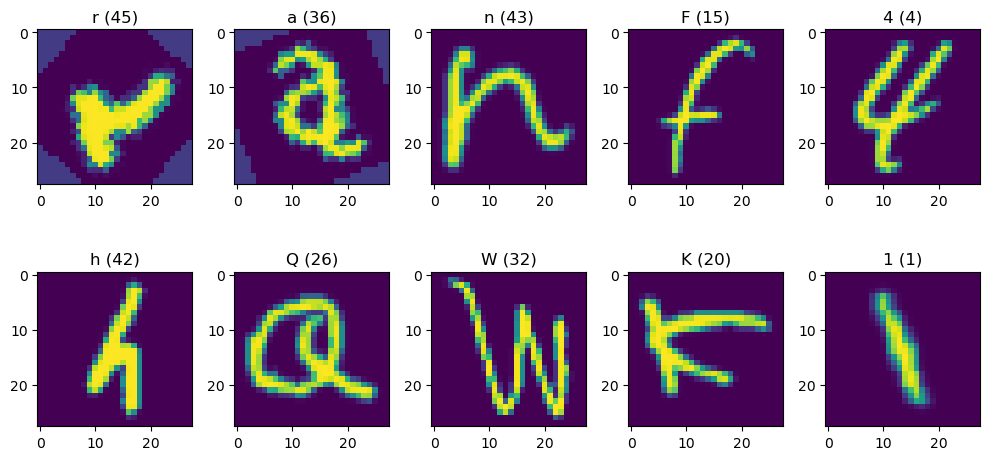

In [5]:
import torchvision.transforms.functional as TF # to rotate 

def show_multiple_images(data):
    # takes input the trianing data and outputs the first 10 photos upright.
    train_loader = DataLoader(data, batch_size=10)
    images, labels = next(iter(train_loader))  # only one batch, we cant index like this [0]
    # cant use PIL rotate because it is a tensor not an image, we access using [C,H,W]

    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    # 1
    img = TF.rotate(images[0], angle=140)
    axes[0,0].imshow(img.squeeze()) # img.squeeze just removes the C axis. 
    axes[0,0].set_title(f"{data.classes[labels[0]]} ({labels[0]})")

    # 2
    img = TF.rotate(images[1], angle=250)
    img = t.flip(img, [2]) # [2] indicates horizontal. 
    axes[0,1].imshow(img.squeeze())
    axes[0,1].set_title(f"{data.classes[labels[1]]} ({labels[1]})")

    # 3
    img = t.rot90(images[2], 3, [1,2]) # [1,2] means both axis and 3 means how many times. 
    img = t.flip(img, [2])
    axes[0,2].imshow(img.squeeze())
    axes[0,2].set_title(f"{data.classes[labels[2]]} ({labels[2]})")

    # 4
    img = t.rot90(images[3], 1, [1,2])
    img = t.flip(img, [1]) # [1] indicates vertical
    axes[0,3].imshow(img.squeeze())
    axes[0,3].set_title(f"{data.classes[labels[3]]} ({labels[3]})")

    # 5
    img = t.rot90(images[4], 1, [1,2])
    img = t.flip(img, [1])
    axes[0,4].imshow(img.squeeze())
    axes[0,4].set_title(f"{data.classes[labels[4]]} ({labels[4]})")

    # 6
    img = t.rot90(images[5], 1, [1,2])
    img = t.flip(img, [1])
    axes[1,0].imshow(img.squeeze())
    axes[1,0].set_title(f"{data.classes[labels[5]]} ({labels[5]})")

    # 7
    axes[1,1].imshow(images[6].squeeze())
    axes[1,1].set_title(f"{data.classes[labels[6]]} ({labels[6]})")

    # 8
    img = t.rot90(images[7], 3, [1,2])
    axes[1,2].imshow(img.squeeze())
    axes[1,2].set_title(f"{data.classes[labels[7]]} ({labels[7]})")

    # 9
    img = t.rot90(images[8], 1, [1,2])
    axes[1,3].imshow(img.squeeze())
    axes[1,3].set_title(f"{data.classes[labels[8]]} ({labels[8]})")

    # 10
    img = t.rot90(images[9], 1, [1,2])
    axes[1,4].imshow(img.squeeze())
    axes[1,4].set_title(f"{data.classes[labels[9]]} ({labels[9]})")

    plt.tight_layout()
    plt.show()
show_multiple_images(training_data)

Create a simple fully connected network.

In [6]:
class SimpleFCNetwork(nn.Module):
    def __init__(self, input_size=784, hidden_size=128, num_classes=47) -> None:
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, num_classes)
        # could also define smth like slef.sequence

    def forward(self, x): # defining how they interact
        x = F.relu(self.fc1(x)) # apply relu for non linearity after layer 1
        x = self.fc2(x) # get output. No need to apply softmax because cross entropy does this. 
        return x 


In [ ]:
def evaluate(model, loader) -> None:
    """Method to evaluate the model on the test dataset.

    Args:
        model (nn.Module): the trained neural network model
        loader (torch.utils.data.DataLoader): the balanced EMNIST test dataset

    Returns:
        float: The accuracy
    """
    correct = 0
    total = 0
    for images, labels in loader: # looping through batches. 
        output = model.forward(x=images.flatten(start_dim=1))
        predicted = output.argmax(dim=1)    

        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    accuracy = correct / total 
    return accuracy

def train_one_epoch(model, train_loader, optimizer, loss_fn):
    """Performs a single training epoch over the entire dataset.

    Args:
        model (nn.Module): The neural network model to be trained.
        train_loader (torch.utils.data.DataLoader): The DataLoader providing
            batches of training data (images and labels).
        optimizer (torch.optim.Optimizer): The optimization algorithm used
            to update model parameters.
        loss_fn (nn.modules.loss._Loss): The loss function used to calculate
            the error.

    Returns:
        float: The cumulative loss for the entire epoch, calculated as the
            sum of losses from each individual batch.
    """
    total_loss = 0 
    for images, labels in train_loader: 
        optimizer.zero_grad() # to clear old gradients. 
        output = model.forward(x=images.flatten(start_dim=1))
        loss = loss_fn(output, labels) # raw output vs expected labels 
        total_loss += loss.item()
        loss.backward() # computes gradients based on loss 
        optimizer.step() # does gradient descent essentially
    return total_loss

def train_num_epochs(model, train_loader, optimizer, loss_fn, num_epochs):
    """Training over multiple epochs. This function repeatedly calls the `train_one_epoch` function, calculates the average loss per batch for each epoch, and prints a progress report to the console. This function shouldn't keep track of the training accuracy and is therefore more efficient than the train_with_accuracyplotting method.

    Args:
        model (nn.Module): The neural network model to be trained.
        train_loader (torch.utils.data.DataLoader): The DataLoader providing
            batches of training data.
        optimizer (torch.optim.Optimizer): The optimization algorithm (e.g., Adam or SGD).
        loss_fn (nn.modules.loss._Loss): The loss function used to evaluate model performance.
        num_epochs (int): The total number of full passes over the training dataset.
    """
    for i in range(num_epochs): 
        train_one_epoch(model, train_loader, optimizer, loss_fn)


def train_num_epochs_and_track_accuracies(
    model, train_loader, test_loader, optimizer, loss_fn, num_epochs
):
    """Trains the model and tracks accuracy for both training and test sets.

    This function performs a full training cycle for a specified number of epochs. After each training pass, it evaluates the model's performance on both the training and test datasets to monitor for convergence and overfitting.

    Args:
        model (nn.Module): The neural network model to be trained.
        train_loader (torch.utils.data.DataLoader): The DataLoader providing training data batches.
        test_loader (torch.utils.data.DataLoader): The DataLoader providing  validation/test data batches.
        optimizer (torch.optim.Optimizer): The optimization algorithm.
        loss_fn (nn.modules.loss._Loss): The loss function used for training.
        num_epochs (int): Total number of times to iterate over the dataset.

    Returns:
        tuple: A tuple containing the trained model and the accuracies
    """
    results_test = np.zeros(num_epochs)
    results_train = np.zeros(num_epochs)
    for i in range(num_epochs): 
        train_one_epoch(model, train_loader, optimizer, loss_fn)
        results_test[i] = evaluate(model,test_loader)
        results_train[i] = evaluate(model,train_loader)

    return (model,np.array([results_train, results_test]))

In [ ]:
def accuracy_curve(model_name, accuracies):
    """
    Creats a line plot of the model's accuracy over the epochs. Compares the train and test accuracy of the various models

    Args:
        model_name: Str
            Name for file naming
        accuracies: List
            List of lists
            Each list is one epoch and contains train-, test- and verification accuracy
    """

    plt.plot([i for i in range(len(accuracies[0]))],accuracies[0],label="train accuracy")
    plt.plot([i for i in range(len(accuracies[0]))],accuracies[1],label="test accuracy")
    plt.legend()
    plt.title(model_name)
    plt.xlabel("epoch count")
    plt.ylabel("accuracy")
    plt.show()


In [ ]:
t.backends.cudnn.benchmark = False
t.backends.cudnn.deterministic = True
t.manual_seed(42)
model = SimpleFCNetwork()
optimizer = optim.SGD(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()
model, accuracies = train_num_epochs_and_track_accuracies(model, DataLoader(training_data, batch_size=64), DataLoader(test_data, batch_size=64), optimizer, loss_fn, 40)
accuracy_curve("simple MLP", accuracies)
t.save(model.state_dict(), "MLP.pt")

KeyboardInterrupt: 

### 🖊️📜 (200 words max)

Explain here:
- How the EMNIST dataset looks like.
- The structure of the network.

The EMNIST dataset had different splits like "balanced" and  "letters" and 4 other. All of them have content that is handwritten, the content depends on the split. All the images are greyscale and 28x28 pixels, the "balanced" split contains 1361,00 characters accross 47 balanced classes where the letters that have a similar capital and non-capital form have their lowercase excluded. Each split is also divided in training and testing sets. 

The structure of the network is that of an MLP with a single hidden layer and one output layer. The input size is 784 as each EMNIST image is 28x28 pixels which flattened is the input, therefore 784 input nodes. After the weighed sum of the input is calculated, it is passed through relu to introduce non-linearity, and then onto the output layer, which computes 47 weighed outputs, one per class. Softmax is not applied in the network itself as it is calculated by the torch function before cross entropy loss is calculated. 

# Part 2: Implement and compare additional Neural Network architectures
In this task you will have to research four different neural network architectures and implement them in this notebook. Explain the structure of those architectures below! Train those model architectures on the EMNIST dataset and compare their accuracies below. Think of a smart way to compare the networks visually in a plot, such as taught in one of the lectures. Also pay attention on which models might be overfitting.

In [ ]:
class CNN_SMALL(nn.Module):
    def __init__(self, num_classes):
        """
        Basic convolutional neural network
            input layer:
            hidden layer:
            output layer: for EMNIST 100

        Args:
            num_classes: int
                The number of classes we want to predict
        """
        super().__init__()

        self.spine = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=5, padding=1), #1 input channel cause EMNIST grayscale, 64 is basic starting filter for edges, 5 is optimal size 
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2,2)), 

            nn.Conv2d(64, 128, kernel_size=3, padding=1), #3 kernel is enough to combine edges etc. into more detailed patterns  
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2,2)), 
        )

        self.avg_pool = nn.AdaptiveAvgPool2d((1,1))

        self.head = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        """
        Define the forward pass of the neural network.

        Args:
            x: torch.Tensor
                The input tensor.

        Returns:
            torch.Tensor
                The output tensor after passing through the network.
        """
        x = self.spine(x)
        x = self.avg_pool(x)
        x = x.flatten(1)
        x = self.head(x)
        return x

In [ ]:
class CNN_BIG(nn.Module):
    def __init__(self, num_classes):
        """
        Advanced convolutional neural network
            input layer:
            hidden layer:
            output layer: for EMNIST 100

        Args:
            num_classes: int
                The number of classes we want to predict
        """
        super().__init__()

        self.spine = nn.Sequential(
            #layer 1
            nn.Conv2d(1, 64, kernel_size=5, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            #layer 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            #layer 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1), #switch cause map is 6x6 so 5 kernel wouldnt do much 
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.head = nn.Sequential(
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        """
        Define the forward pass of the neural network.

        Args:
            x: torch.Tensor
                The input tensor.

        Returns:
            torch.Tensor
                The output tensor after passing through the network.
        """
        x = self.spine(x)
        x = self.avg_pool(x)
        x = x.flatten(1)
        return self.head(x)


In [ ]:
class BasicBlock(nn.Module):
    """Standard residual block used in ResNet architectures."""

    def __init__(self, in_channels, out_channels, stride):
        """Initializes the BasicBlock.

        Args:
            in_channels (int): Number of input channels.
            out_channels (int): Number of output channels for the first convolution.
            stride (int, optional): Stride for the first convolutional layer. Default is 1.
        """
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,stride=stride, padding=1, bias=False) #3 is standard resnet to be spatial and datailed, (BatchNorm has alresdy bias)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        #when shapes already matched
        self.shortcut = nn.Sequential() 
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False), #just passes and downsample, 1 kernel doesnt look spatially
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        """
        Define the forward pass of the neural network.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor after passing through the network.
        """
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x) 
        return self.relu(out)


class ResNet(nn.Module):
    """Generic ResNet architecture implementation.

    This class constructs a Deep Residual Network by stacking multiple layers, where each layer contains a specific number of residual blocks (BasicBlock or
    Bottleneck).
    """

    def __init__(self, block, num_block, num_classes):
        """
        Initializes the ResNet model.

        Args:
            block (nn.Module): The block class to use.
            num_block (list[int]): A list of 4 integers defining the number of blocks
                in each of the four stages
            num_classes (int, optional): Number of output classes.
            name (str, optional): Name of the model. Default is "resnet".
        """
        super().__init__()
        self.in_channels = 64

        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False), #3 cause emnist small
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        self.layer1 = self._make_layer(block,  64, num_block[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_block[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_block[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_block[3], stride=2)

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        """make resnet layers(by layer i didnt mean this 'layer' was the
        same as a neuron netowork layer, ex. conv layer), one layer may
        contain more than one residual block

        Args:
            block: block type, basic block or bottle neck block
            out_channels: output depth channel number of this layer
            num_blocks: how many blocks per layer
            stride: the stride of the first block of this layer

        Return:
            return a resnet layer
        """
        strides = [stride] + [1] * (num_blocks - 1)
        layers  = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels
        return nn.Sequential(*layers) #layers[0], layers[1], layers[2]

    def forward(self, x):
        """
        Forward pass of the ResNet.

        Args:
            x (torch.Tensor): Input tensor of shape .

        Returns:
            torch.Tensor: Unnormalized log probabilities (logits) of shape (Batch, num_classes).
        """
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avg_pool(x)
        x = x.flatten(1)
        return self.fc(x)

In [ ]:
def calculate_accuracy(model, loader, device):
    """Evaluate a model on a dataloader and return accuracy in percent."""
    model.eval()
    correct = 0
    total = 0
    with t.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(imgs)
            preds  = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total  += labels.size(0)
    return (correct / total) * 100

def full_training_loop_and_store_accuracies(ModelType, train_loader, val_loader, device, num_epochs = 10, lr=0.001, weight_decay=0.0, label_smoothing=0.1, track_train_acc= True, save_checkpoint= True, save_path = "best_model.pt", model_name = "model"):
    """
    Implement code to create an instance of the model and run a full training loop while recording the accuracies. Then, save the accuracies for later uses.
    """
    model = ModelType.to(device)
    
    loss_fn = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
 
    history = {
        "train_loss": [], 
        "train_acc": [], 
        "val_acc": []}
    best_val_acc = 0.0
 
    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
 
        for imgs, labels in tqdm(train_loader, desc=f"[{model_name}] Epoch {epoch}/{num_epochs}", leave=False):
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
                   
            # zero gradients
            optimizer.zero_grad(set_to_none=True)
            
            # standard forward and backward pass
            loss = loss_fn(model(imgs), labels)
            loss.backward()
            optimizer.step()
 
            running_loss += loss.item() * imgs.size(0) 
 
        scheduler.step()
 
        #train accuracy to look for overfitting
        train_acc = 0.0
        if track_train_acc:
            train_acc = calculate_accuracy(model, train_loader, device)
        epoch_loss = running_loss / len(train_loader.dataset)
        val_acc = calculate_accuracy(model, val_loader, device)
 
        history["train_loss"].append(epoch_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
 
        print(f"Epoch {epoch:02d} | Train loss: {history['train_loss'][epoch-1]:.4f} | "
              f"Train Accuracy: {history['train_acc'][epoch-1]:.2f}% | Validation Accuracy: {history['val_acc'][epoch-1]:.2f}%")
 
        #checkpoint to save only the best val
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            
            if save_checkpoint:
                checkpoint = {
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'accuracy': val_acc,
                    'loss': epoch_loss
                }
                t.save(checkpoint, save_path)  # save the checkpoint
                print(f'New best model with Val Accuracy: {val_acc:.2f}% saved to {save_path}')
            else:
                print(f'New best model found with Val Accuracy: {val_acc:.2f}% (Not saved to disk)')
            
    return history
 

def load_accuracies_and_create_plots(model_name, accuracies):
    """
    Implement code to load the previously stored accuracies, evaluate the models and create plots.
    """
    epochs = range(1, len(accuracies["val_acc"]) + 1)

    train_acc = accuracies["train_acc"]
    val_acc = accuracies["val_acc"]
    train_loss = accuracies["train_loss"]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7), sharex=True)
    
    # accuracy
    ax1.plot(
    epochs,
    train_acc,
    label='Train Accuracy',
    marker='o',
    markersize=4
    )
    
    ax1.plot(
    epochs,
    val_acc,
    label='Validation Accuracy',
    marker='o',
    markersize=4
    )
    
    ax1.set_title('Training vs Validation Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_ylim(55, 100)
    ax1.grid(alpha=0.3)
    ax1.legend()
    
    # loss
    ax2.plot(
    epochs,
    train_loss,
    label='Training Loss',
    color='tab:orange',
    marker='o',
    markersize=4
    )
    
    ax2.set_title('Training Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_ylim(0.7, 2.7)
    ax2.grid(alpha=0.3)
    ax2.legend()
    
    fig.suptitle(f'{model_name} performance', fontsize=14)
    
    plt.tight_layout()
    plt.show()


In [ ]:
def comparison_plot(accuracies):
    """
    Creats a bar plot comparing the train and test accuracies of the three models.

    Args:
        accuracies: List
            List of dictionaries containing the accuracies
            Each entry in the list is one model
    """
    model_names = [acc["name"] for acc in accuracies]
    train_finals = [acc["history"]["train_acc"][-1] for acc in accuracies]
    val_finals = [acc["history"]["val_acc"][-1] for acc in accuracies]

    x = np.arange(len(model_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))

    bars_train = ax.bar(x-width/2, train_finals, width, label="train accuracy")
    bars_val = ax.bar(x+width/2, val_finals, width, label="validation accuracy")

    ax.bar_label(bars_train,fmt="%.1f%%", padding=3, fontsize=9)
    ax.bar_label(bars_val, fmt="%.1f%%", padding=3, fontsize=9)

    ax.set_title("Model comparison")
    ax.set_xlabel("Model")
    ax.set_ylabel("Accuracy (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.set_ylim(0, 110)
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
    
    plt.show()

In [ ]:
t.backends.cudnn.benchmark = False
t.backends.cudnn.deterministic = True
t.manual_seed(42)

batch_size = 256
epochs = 10
num_classes = len(training_data.classes)

_g = t.Generator().manual_seed(42)
train_loader = DataLoader(
    training_data, batch_size=batch_size, shuffle=True,
    num_workers=0, pin_memory=True,
    generator=_g
)
test_loader = DataLoader(
    test_data, batch_size=batch_size, shuffle=False,
    num_workers=0, pin_memory=True,
)

history_small = full_training_loop_and_store_accuracies(
     ModelType = CNN_SMALL(num_classes=47),
     train_loader = train_loader,
     val_loader = test_loader,
     device = device,
     model_name = "CNN_SMALL",
     save_path= "CNN_SMALL.pt"
 )

history_big = full_training_loop_and_store_accuracies(
    ModelType = CNN_BIG(num_classes=47),
    train_loader = train_loader,
    val_loader = test_loader,
    device = device,
    model_name = "CNN_BIG",
    save_path = "CNN_BIG.pt",
)

history_resnet = full_training_loop_and_store_accuracies(
    ModelType=ResNet(
        block=BasicBlock,
        num_block=[2, 2, 2, 2],
        num_classes=47
    ),
    train_loader=train_loader,
    val_loader=test_loader,
    device=device,
    model_name="ResNet",
    save_path="ResNet.pt"
)

load_accuracies_and_create_plots("CNN_SMALL", history_small)
load_accuracies_and_create_plots("CNN_BIG", history_big)
load_accuracies_and_create_plots("ResNet", history_resnet)

comparison_plot([
    {"name": "CNN_SMALL", "history": history_small},
    {"name": "CNN_BIG", "history": history_big},
    {"name": "ResNet", "history": history_resnet},
])

### 🖊️📜 (400 words max)

Discuss here the structure of the implemented neural network architectures and analyse the plots you created in order to compare their performances.  

Small and Big CNN share the same architecture pattern. The main difference lies in depth. Each convolutional layer consists of Conv2d(), which slides a kernel across the image to detect patterns, BatchNorm2d() for output normalisation, ReLU to introduce non-linearity by replacing negative values with 0, and MaxPool2d() to reduce the spatial size. The first layer uses 64 filters with a 5×5 kernel to detect simple edges and strokes, while the second uses 128 filters with a 3×3 kernel to combine those into more complex patterns. The head consists of two linear layers - the first learns combinations of features, the second assigns a score to each class, with the highest score being the final prediction. Dropout is applied between them to reduce overfitting. Big CNN adds a third convolutional layer with 256 filters, allowing it to learn deeper the feature combinations before classification.

ResNet introduces a different approach through residual blocks. Each BasicBlock has two paths: the main convolution path and a shortcut that adds the original input to the output. This means it learns the residual difference rather than a full transformation, which prevents the vanishing gradient problem. If spatial size or channel’s number changes, the shortcut path matches the dimensions. The network is organised into 4 stages, each doubling the filters, while reducing the spatial size by half with stride=2 on the first block of each stage. The last classifying layer is similar to CNN.

The results align with expectations. ResNet has the highest accuracy on both training and validation sets. This is likely due to its depth and use of residual blocks to improve gradient when we have many layers. Small CNN performs the worst, because of it being shallow and having less filters. Big CNN accuracy resembles much more ResNet than Small CNN, making adding a layer a big improvement. All models show a gap between training and validation accuracy, which is expected on the unseen data. This gap is largest in ResNet - it is prone to overfit (not that significant here). Small CNN has the smallest gap, due to simplicity - it cannot learn well enough to overfit. Training loss is the lowest in ResNet, because it is deeper and learns better representation while having optimized gradients. The difference is noticeable when compared to Big CNN, making it less confident than ResNet. A big improvement of the loss is seen when comparing Big to Small CNN.

## Part 3: Hyperparameter Optimisation Study
In this task, you will learn how to perform a hyperparameter optimisation study. Training a neural network involves different parameters, like batch size, learning rate, weight decay etc. Those parameters have to be set before the training and their choice determines if the network converges at all and how well the network performs in the end. 

There are various ways to perform hyperparameter optimisation, but the basic idea is to search the best possible combination of parameters in terms of network performance. For that a network can be trained for a few epochs for each parameter combination and evaluated. The best performing combination should then be chosen and the network can be trained for the total desired amount of epochs with the optimized hyperparameters. Perform the hyperparameter optimisation for the **big CNN** model with 25 trials! You are allowed to take a section of the train set as a validation set for the hyperparameter optimisation!

We will not focus on the theory (grid search, random search, bayesian optimisation) behind it, the scope of this task is that you have performed HPO at least once in your studies and that you know how it practically works.

In [ ]:
# Don't forget to do a train/validation/test split
from torch.utils.data import random_split

t.manual_seed(42)

# take training data and split to get validation sey

train_size = int(0.9 * len(training_data))
val_size = len(training_data) - train_size

train_dataset, val_dataset = random_split(
    training_data,
    [train_size, val_size],
)

def objective(trial):
    """
    Objective function for hyperparameter optimization using Optuna. It suggests a set of hyperparameters, initializes model and optizer, trains the model for a fixed number of epochs and returns the validation accuracy.

    Args:
        trial (optuna.trial.Trial): A specific trial object provided by the
            Optuna study to suggest hyperparameters and report progress.

    Returns:
        float: The final validation accuracy of the model, used by Optuna
            to evaluate the quality of the suggested hyperparameters.
    """
    t.manual_seed(42)

    # suggest values to derive from to find best parameters

    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])

    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-2,
        log=True
    )

    dropout = trial.suggest_float("dropout", 0.2, 0.6)

    label_smoothing = trial.suggest_float(
        "label_smoothing",
        0.0,
        0.2
    )

  # take a subset of the data and load (using the whole dataset will take too long)

    small_train = t.utils.data.Subset(train_dataset, range(20000))
    small_val = t.utils.data.Subset(val_dataset, range(5000))

    train_loader = DataLoader(
        small_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True
    )

    val_loader = DataLoader(
        small_val,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    model = CNN_BIG(num_classes=47)

    model.head[2] = nn.Dropout(dropout)

    model = model.to(device)

    optimizer = optim.AdamW( # AdamW is preferred for CNN_BIG
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    loss_fn = nn.CrossEntropyLoss(
        label_smoothing=label_smoothing
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=2
    )

    num_epochs = 2

    # train model

    for epoch in range(num_epochs):

        model.train()

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

        scheduler.step()

        # validation accuracy
        val_acc = calculate_accuracy(model, val_loader, device)

        # report intermediate value to Optuna
        trial.report(val_acc, epoch)

        # pruning bad trials early (added for speed)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    # cleanup memory
    del model
    del optimizer
    gc.collect()

    if t.cuda.is_available():
        t.cuda.empty_cache()

    return val_acc

In [ ]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42), # deterministic study
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=1), # pruner for speed
    study_name="cnn_big_hpo"
)

# run optimization
study.optimize(
    objective,
    n_trials=25,
    show_progress_bar=True
)



print("\nBest trial:")
best_trial = study.best_trial

print(f"Validation Accuracy: {best_trial.value:.2f}%")

# show and save final results

print("\nBest hyperparameters:")
for key, value in best_trial.params.items():
    print(f"{key}: {value}")

[I 2026-05-21 15:55:21,378] A new study created in memory with name: cnn_big_hpo
Best trial: 0. Best value: 60.92:   4%|▍         | 1/25 [00:43<17:26, 43.61s/it]

[I 2026-05-21 15:56:04,986] Trial 0 finished with value: 60.919999999999995 and parameters: {'batch_size': 256, 'lr': 0.0010401663679887319, 'weight_decay': 4.2079886696066345e-06, 'dropout': 0.26239780813448105, 'label_smoothing': 0.011616722433639893}. Best is trial 0 with value: 60.919999999999995.


Best trial: 0. Best value: 60.92:   8%|▊         | 2/25 [01:26<16:38, 43.43s/it]

[I 2026-05-21 15:56:48,289] Trial 1 finished with value: 38.0 and parameters: {'batch_size': 128, 'lr': 0.00010838581269344756, 'weight_decay': 0.00757947995334801, 'dropout': 0.5329770563201687, 'label_smoothing': 0.04246782213565523}. Best is trial 0 with value: 60.919999999999995.


Best trial: 0. Best value: 60.92:  12%|█▏        | 3/25 [02:18<17:13, 46.97s/it]

...

[I 2026-05-21 16:13:04,244] Trial 22 finished with value: 76.72 and parameters: {'batch_size': 128, 'lr': 0.0007919808490585603, 'weight_decay': 5.639268806201441e-06, 'dropout': 0.3882222148911812, 'label_smoothing': 0.17098103404789572}. Best is trial 22 with value: 76.72.


Best trial: 22. Best value: 76.72:  96%|█████████▌| 24/25 [18:29<00:47, 47.20s/it]

[I 2026-05-21 16:13:50,829] Trial 23 finished with value: 75.96000000000001 and parameters: {'batch_size': 128, 'lr': 0.0008739289703129685, 'weight_decay': 4.817846089408331e-06, 'dropout': 0.39457426722297667, 'label_smoothing': 0.16792745346035587}. Best is trial 22 with value: 76.72.


Best trial: 22. Best value: 76.72: 100%|██████████| 25/25 [19:19<00:00, 46.38s/it]

[I 2026-05-21 16:14:40,912] Trial 24 finished with value: 73.38 and parameters: {'batch_size': 128, 'lr': 0.00045968465206698333, 'weight_decay': 5.710007722202139e-06, 'dropout': 0.45467955314660086, 'label_smoothing': 0.17166156945664143}. Best is trial 22 with value: 76.72.

Best trial:
Validation Accuracy: 76.72%

Best hyperparameters:
batch_size: 128
lr: 0.0007919808490585603
weight_decay: 5.639268806201441e-06
dropout: 0.3882222148911812
label_smoothing: 0.17098103404789572


Now that you have found the best parameters for the network to train, use them to train the network for 10 epochs and analyse it in your report. Compare the network accuracy you achieve now with the accuracy you previously achieved!

In [ ]:
# load data

final_train_loader = DataLoader(
    train_dataset,
    batch_size=best_trial.params["batch_size"],
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

final_val_loader = DataLoader(
    val_dataset,
    batch_size=best_trial.params["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


t.manual_seed(42)
model = CNN_BIG(num_classes=47)
model.head[2] = nn.Dropout(best_trial.params["dropout"])

optimizer = optim.AdamW(
    model.parameters(),
    lr=best_trial.params["lr"],
    weight_decay=best_trial.params["weight_decay"]
)

loss_fn = nn.CrossEntropyLoss(
    label_smoothing=best_trial.params["label_smoothing"]
)

# fully train model based on parameters found

history = full_training_loop_and_store_accuracies(
    ModelType=model,
    train_loader=final_train_loader,
    val_loader=final_val_loader,
    device=device,
    num_epochs=10,
    lr=best_trial.params["lr"],
    weight_decay=best_trial.params["weight_decay"],
    label_smoothing=best_trial.params["label_smoothing"],
    model_name="CNN_BIG_HPO"
)

# plots

load_accuracies_and_create_plots(
    "CNN_BIG_HPO",
    history
)

print(f"Best validation accuracy: {max(history['val_acc']):.2f}%")

Epoch 01 | Train loss: 1.9841 | Train Accuracy: 80.17% | Validation Accuracy: 80.27%
New best model with Val Accuracy: 80.27% saved to best_model.pt


Epoch 02 | Train loss: 1.5922 | Train Accuracy: 85.92% | Validation Accuracy: 85.22%
New best model with Val Accuracy: 85.22% saved to best_model.pt


Epoch 03 | Train loss: 1.5290 | Train Accuracy: 87.97% | Validation Accuracy: 87.01%
New best model with Val Accuracy: 87.01% saved to best_model.pt


Epoch 04 | Train loss: 1.4951 | Train Accuracy: 88.38% | Validation Accuracy: 87.71%
New best model with Val Accuracy: 87.71% saved to best_model.pt


Epoch 05 | Train loss: 1.4710 | Train Accuracy: 89.59% | Validation Accuracy: 88.99%
New best model with Val Accuracy: 88.99% saved to best_model.pt


Epoch 06 | Train loss: 1.4500 | Train Accuracy: 89.94% | Validation Accuracy: 89.10%
New best model with Val Accuracy: 89.10% saved to best_model.pt


Epoch 07 | Train loss: 1.4338 | Train Accuracy: 90.52% | Validation Accuracy: 89.68%
New best model with Val Accuracy: 89.68% saved to best_model.pt


Epoch 08 | Train loss: 1.4197 | Train Accuracy: 90.90% | Validation Accuracy: 89.69%
New best model with Val Accuracy: 89.69% saved to best_model.pt


Epoch 09 | Train loss: 1.4101 | Train Accuracy: 91.19% | Validation Accuracy: 89.77%
New best model with Val Accuracy: 89.77% saved to best_model.pt


### 🖊️📜 (250 words max)

Explain here how you implemented the hyperparameter optimization study, which hyperparameter search space you chose, how the newly obtained model compares to the previous models and why and what might be the pitfalls of HPO.

The hyperparameter optimization study was implemented using Optuna on the CNN_BIG architecture. Firstly, the training dataset was retrieved, with 10% of it detached from the rest in order to serve as a validation set. However, only 20000 training samples and 5000 validation samples were used, in order to make the training process faster. On every trial, the model was trained for two epochs and evaluated on the validation set. The validation accuracy was returned to Optuna, which selected the best-performing parameter combination over 25 trials.

The hyperparameter search space was the batch size [128, 256, 512], the learning rate (1e-4 - 5e-3), the weight decay (1e-6 - 1e-2), the dropout rate (0.2 - 0.6), and the label smoothing (0 - 0.2). This search space was chosen because testing and research showed that accurate BIG_CNN models have values that rest within the search space chosen.

The new CNN_BIG model performs better than the old one, with a higher validation accuracy. This observation is due to the discovery of better parameters found during the HPO process, yielding better results.

One flaw of HPO is the added cost of finding optimized parameters, at the trade-off of an often negligible performance increase. Even on this model, the improvement is within the 1-3% range. Therefore, it is up to the researcher to decide whether it is worth it to implement HPO. The computational cost can always be reduced by implementing shorter training runs, but this sacrifices on the accuracy of the optimized parameters.

## Part 4: Explainable AI

In this task, you will learn about Explainable AI. This is a branch of AI that seeks to develop methods that help us explain why AI models behave as they do. For this assignment, we will focus on probing, although there are many other XAI methods. Probing is a technique that seeks to determine whether a particular concept is "stored" at a particular layer in a model. For example, in a model as  any of the ones in this assingment, we may want to determine if this model stores information on whether this character is a number or a letter, when presented with a character. While the final task does not differentiate between numbers and letters, it is possible that the model still makes this distinction somewhere througout its layers. In order to discover this, we can follow this process:

- Feed the model EMNIST images and let it perform inference, but record the activations of the model at each of its layers for each image shown. Do this to create train and test activation sets and save them.
- Train a very simple model, which we call a probe, with the input being the activations of the original model at a particular layer, and the output being whether this character is a number or a letter. The model should be very simple (e.g linear regression).
- Test this probe on the test set of activations, and observe how well the probe is at predicting whether a character is a number or a letter by only looking at the activations at a particular layer.
- Train another probe at the same layer, but in this case, instead of making it predict whether a character is a number or a letter, make it predict a random meaningless task with the same structure as the standard task (so it should also be binary and have similar label quantity proportions. For example, here there are two reasonable control tasks: first one is give each character a number/letter label randomly, so all "a"s become a number, "b"s a letter, "7"s a letter, etc. Second one is give each image a number/letter label randomly regardless of its character). Then, test this control probe (the test set should also use control labels generated in the same random way)
- If the standard probe performs better than the control probe, this indicates that the activations at this layer contain some information that encodes whether the character was a letter or a number.
- We do the same thing for all layers to observe at what layers this information is most clearly encoded.

Your task for this part of the assignment is to perform a small probing study with the **big CNN model**. You need to set up the code infrastructure to carry out probing experiments, and report the results along with a reflection on what these results may mean. **Remember to also create a control task for each of these tasks**; this is very important, and for each task you should think carefully about the way the control task labels should be created. To ensure a reasonable computation time, you should generate the activations of **at most** 2560 images per split to run your study. These are the specific tasks you need to implement:

### Task 1

Make a probe that predicts if the image contains a letter or a number.

### Task 2

Make a probe that predicts the amount of closed segments in the image. For example, "9" has one closed circle, "8" has two, "a" has one, and "T" has zero. Since this may depend on the font (e.g "g" can have 1 or 2 depending on the font), determining the number of segments for every single image in the EMNIST dataset is challenging. To simplify the task, you can assume every image associated with each of these characters has the same number of closed segments and use the following list:

- 1 closed segment: 0, 4, 6, 9, a, b, d, e, o, p, q, A, D, O, P, Q, R
- 2 closed segments: 8, g, B
- 0 closed segments: everything else

Take into account that EMNIST balance merges some characters that are considered potentially indistinguishable in written form, such as "o" and "O".

### Task 3

Make a probe that performs the same task as the model it is built on top of (predict the specific character class present in the image).

### Task 4

Come up with a new probing task and implement it. Explain why this task is interesting.

In [ ]:
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from random import seed
import random
from typing import Any, Callable
from pathlib import Path


class ActivationLoader:
    """Loads a model and extracts activations from its layers"""

    def __init__(self, model):
        self.model = model

        # Dictionary to store collected activations per layer
        self.activations = {}
        # List to track registered hooks so they can be removed later
        self.hooks = []

        # Map human-readable layer names to actual model submodules
        self.layers = {
            "conv1": self.model.spine[0],
            "conv2": self.model.spine[4],
            "conv3": self.model.spine[8],
            "avg_pool": self.model.avg_pool,
            "head": self.model.head,
        }

        # Register a forward hook on each layer to capture its output
        for layer_name, layer in self.layers.items():
            self.activations[layer_name] = []
            hook = layer.register_forward_hook(self.save_activations(layer_name))
            self.hooks.append(hook)

    def save_activations(self, layer_name):
        # Returns a hook function that appends flattened activations to the layer's list
        def hook(module, input, output):
            # Detach from computation graph, move to CPU, and flatten all dims except batch
            self.activations[layer_name].append(output.detach().cpu().flatten(1))
        return hook

    def remove_hooks(self):
        # Deregister all hooks to avoid memory leaks or unintended side effects
        for hook in self.hooks:
            hook.remove()

    def generate_activations(
        self,
        dataloader: t.utils.data.DataLoader,
        split: str,
        save_to_disk: bool,
        amount_to_generate: int,
    ) -> None:
        """
        Extract activations from all layers by running forward passes
        through the dataloader.

        Args:
            dataloader: DataLoader with images and labels for activation extraction
            split: Either "train" or "test" for naming saved files
            save_to_disk: Whether to save activations to disk
            amount_to_generate: Maximum number of samples to extract activations for
        """
        # Reset activation buffers before a new extraction run
        for key in self.activations:
            self.activations[key] = []

        true_labels = []
        total = 0

        # Set model to eval mode to disable dropout/batchnorm training behaviour
        self.model.eval()

        for images, labels in dataloader:
            # Stop once we've collected enough samples
            if total >= amount_to_generate:
                break

            # Only take as many samples as we still need
            remainder = amount_to_generate - total

            if len(images) > remainder:
                images = images[:remainder]
                labels = labels[:remainder]

            # Forward pass triggers all registered hooks; no gradients needed
            with t.no_grad():
                self.model(images)

            true_labels.append(labels)
            total += len(images)

        # Concatenate per-batch activation lists into single tensors per layer
        new_activations = {}
        for label, groups in self.activations.items():
            new_activations[label] = t.cat(groups, dim=0)

        self.activations = new_activations
        # Concatenate all batch labels into one tensor
        self.labels = t.cat(true_labels, dim=0)

        if save_to_disk:
            for name, activation in self.activations.items():
                t.save(activation, f"activations_{split}_{name}.pt")
            t.save(self.labels, f"labels_{split}.pt")
            print(f"saved {total} for group='{split}'")


class Probe:
    """
    Probe for classification tasks on neural network activations. Uses logistic
    regression as the linear model.
    """

    def __init__(self, classes: list) -> None:
        self.classes = classes
        # Linear classifier trained on scaled activations
        self.logistic_regression = LogisticRegression(random_state=67)
        # Scaler fitted on training activations; applied to test activations too
        self.scaler = StandardScaler()

    def create_probe_from_data(self, acts: t.Tensor, labels: t.Tensor) -> "Probe":
        """
        Create and train a Probe.

        Args:
            acts: Activation tensor of shape (num_samples, activation_dim)
            labels: Label tensor of shape (num_samples,) for classification targets

        Returns:
            Trained Probe instance ready for inference
        """
        # Standardise activations to zero mean and unit variance before fitting
        acts_scaled = self.scaler.fit_transform(acts.numpy())
        self.logistic_regression.fit(acts_scaled, labels.numpy())
        return self


def generate_all_labels_of_probing_tasks(original_labels, task, classes):
    """
    Implement a function that takes in the original labels of the dataset,
    and based on these creates the labels required for every probing task.
    Make sure to include the control tasks too.
    """
    # Characters with exactly one closed segment (loop)
    one_closed_seg = {'0', '4', '6', '9', 'a', 'b', 'd', 'e', 'o', 'p', 'q', 'A', 'D', 'O', 'P', 'Q', 'R'}
    # Characters with exactly two closed segments
    two_closed_seg = {'8', 'g', 'B'}
    # Characters that are visually symmetric about a vertical or horizontal axis
    symmetric = {'A', 'H', 'I', 'M', 'O', 'T', 'U', 'V', 'W', 'X', 'Y', '0', '1', '8', 'D', 'C', '3'}

    # Convert integer labels back to their character representations
    char_labels = [classes[lbl] for lbl in original_labels]

    if task == 1:
        # Binary: 1 if alphabetic character, 0 if digit
        task_labels = [1 if c.isalpha() else 0 for c in char_labels]
        # Control: same label distribution but randomly shuffled (breaks spatial signal)
        control = task_labels.copy()
        random.seed(42)
        random.shuffle(control)
        return task_labels, control

    elif task == 2:
        # Multi-class: 0 = no closed segment, 1 = one closed segment, 2 = two closed segments
        task_labels = []
        for c in char_labels:
            if c in one_closed_seg:
                task_labels.append(1)
            elif c in two_closed_seg:
                task_labels.append(2)
            else:
                task_labels.append(0)
        control = task_labels.copy()
        random.seed(42)
        random.shuffle(control)
        return task_labels, control

    elif task == 3:
        # Identity task: predict the original class index directly
        task_labels = original_labels.copy()
        control = task_labels.copy()
        random.seed(42)
        random.shuffle(control)
        return task_labels, control

    elif task == 4:
        # Binary: 1 if the character has reflective symmetry, 0 otherwise
        task_labels = [1 if c in symmetric else 0 for c in char_labels]
        control = task_labels.copy()
        random.seed(42)
        random.shuffle(control)
        return task_labels, control

    else:
        raise ValueError("There are only 4 tasks!")

def plot_metrics(results: dict) -> None:
    """
    Plot the accuracy (or precision, recall, f1 or whichever metric you see fit)
    of the probe predictions over the layers (one line for the probe trained on
    the standard task. Another line for the probe trained on the control task)
    """

    layers = ["conv1", "conv2", "conv3", "avg_pool", "head"]
    num_tasks = len(results)
    
    # One subplot per probing task, arranged in a single row
    fig, axes = plt.subplots(1, num_tasks, figsize=(5 * num_tasks, 4))
    
    for ax, (task, layer_results) in zip(axes, results.items()):
        # Extract accuracy for the real task and the shuffled control at each layer
        real_accs = [layer_results[l][0] for l in layers]
        control_accs = [layer_results[l][1] for l in layers]
        
        # Solid line for the genuine probing task
        ax.plot(layers, real_accs, label="standard", marker="o")
        # Dashed line for the control (chance-level baseline)
        ax.plot(layers, control_accs, label="control", marker="o", linestyle="--")
        ax.set_title(f"Task {task}")
        ax.set_xlabel("Layer")
        ax.set_ylabel("Accuracy")
        ax.set_ylim(0, 1)
        ax.legend()
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

# Load trained big CNN
big_cnn = CNN_BIG(num_classes=47)
big_cnn.load_state_dict(t.load("CNN_BIG.pt", map_location=device)["model_state_dict"])
big_cnn.to(device)

# Dataloaders with shuffle=False so labels stay consistent
train_loader_probe = DataLoader(training_data, batch_size=64, shuffle=False)
test_loader_probe  = DataLoader(test_data,     batch_size=64, shuffle=False)

# Generate activations
activation_loader = ActivationLoader(big_cnn)

activation_loader.generate_activations(train_loader_probe, split="train", save_to_disk=True, amount_to_generate=2560)
train_activations = {k: v.clone() for k, v in activation_loader.activations.items()}
train_labels_raw  = activation_loader.labels.clone()

activation_loader.generate_activations(test_loader_probe, split="test", save_to_disk=True, amount_to_generate=2560)
test_activations = {k: v.clone() for k, v in activation_loader.activations.items()}
test_labels_raw  = activation_loader.labels.clone()

activation_loader.remove_hooks()

# Train probes and collect results
layers  = ["conv1", "conv2", "conv3", "avg_pool", "head"]
results = {}

for task in range(1, 5):
    results[task] = {}

    real_train, ctrl_train = generate_all_labels_of_probing_tasks(list(train_labels_raw.numpy()), task, training_data.classes)
    real_test,  ctrl_test  = generate_all_labels_of_probing_tasks(list(test_labels_raw.numpy()),  task, training_data.classes)

    real_train_t = t.tensor(real_train)
    ctrl_train_t = t.tensor(ctrl_train)
    real_test_t  = t.tensor(real_test)
    ctrl_test_t  = t.tensor(ctrl_test)

    for layer in layers:
        train_acts = train_activations[layer]
        test_acts  = test_activations[layer]

        real_probe = Probe(classes=list(set(real_train)))
        real_probe.create_probe_from_data(train_acts, real_train_t)
        real_preds = real_probe.logistic_regression.predict(
            real_probe.scaler.transform(test_acts.numpy())
        )
        real_acc = accuracy_score(real_test_t.numpy(), real_preds)

        ctrl_probe = Probe(classes=list(set(ctrl_train)))
        ctrl_probe.create_probe_from_data(train_acts, ctrl_train_t)
        ctrl_preds = ctrl_probe.logistic_regression.predict(
            ctrl_probe.scaler.transform(test_acts.numpy())
        )
        ctrl_acc = accuracy_score(ctrl_test_t.numpy(), ctrl_preds)

        results[task][layer] = (real_acc, ctrl_acc)
        print(f"Task {task} | {layer:10s} | real: {real_acc:.3f} | control: {ctrl_acc:.3f}")

plot_metrics(results)

### 🖊️📜 (200 words max)
Answer the following:

- Why is a control task necessary? Couldn't we just do the standard task?
- Why do we use very simple models as probes? Wouldn't a neural network with many layers be better?
- If a probing experiment gives positive results, does this necessarily mean that the model actually uses this information during inference? Why or why not?
- Why would we ask you to do a probing task that is the same as the original task (character classification)? Does this probing task tell us anything new compared to just observing the original model's performance?


1) The control is necessary as it helps verify whether the probes can make actual predictions from the representations. The control helps us identify how the probes work, by generating random labels, they learn noise. If the standard task performs much better than the control task, we become more confident that the probe is working on identifying real features, and that it performs better than random guessing based on the label distribution.

2) We use simple probes because we are only interested in how each layer can predict based on the limited knowledge gathered from it. If we made the probe too powerful, then it could learn to solve the task regardless of the features derived.

3) It is hard to say for certain. We only gather what patterns and features are retrieved by each layer. However, this does not necessarily tell us if the network uses this information to make inferences.

4) The probing task that is the same as the original task gives us an insight on how each individual layer performs in gathering relevant data for character identification. This helps evaluate efficiency if we can track whether or where there is sufficient information gathered. This in turn helps better plan the architecture of the network. 


### 🖊️📜 (50 words max)

What probe did you make for task 4? What was the idea behind it?

We chose to probe for horizontal or/and vertical symmetry as we noticed that quite a few characters had this characteristic. This is a more complex task than, for example, just detecting edges. Hence, we wanted to see if the deeper layers would capture it better. 


### 🖊️📜 (300 words max)

Make a small report on your results. What do you observe looking at the graphs? Can you explain why your curves may look like this? What do they tell you about whether (and if so, at what layers) the model stores any of the concepts we were trying to probe for?


The graphs show a positive growth trend with each additional layer across all four tasks suggesting that all the layers do contribute to encoding task-relevant information. However, the shape of the curves vary between the tasks with layers contributing differently to how much the accuracy is increased. 

For Task 1 the curve is the most linear, with each layer contributing roughly equally to accuracy. This suggests that distinguishing between letters and numbers is not inherent to any specific layers, but the accuracy builds gradually. This might be due to the overlap in the structure between letters and numbers as both contain similar shapes like edges and curves. Despite the steady increase in accuracy, the “head” layer contributes slightly less to the increase compared to other layers. This might be because that layer is a more task-specific part of the model which does not help as much with this task. 

For Task 2 and 3, the line is more curved than for Task 1. There is a more unequal distribution of how accuracy increases with each layer. For Task 3, the accuracy is already high once the “conv3” layer is reached. This might be because the earlier layers are good at identifying geometric features. The next two layers increase the accuracy only slightly, and by the last layer there is barely any change in accuracy. For Task 3, a similar pattern is observed, but with a lower accuracy. 

For task 4, layers from “conv1” to “conv3” show a steady and roughly equal increase in accuracy. However, unlike the other tasks, where the “head” layer contributed minimally to an increase in accuracy, in this task this contribution is noticeable. This could be attributed to the task of identifying symmetry being more abstract, with earlier layers not seeing the full image. Hence, the “head” layer may be more suitable in encoding the structure for this task compared to other tasks. 